## Random Forest Project
### Netflix Customer Churn CSV Dataset

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

## 1) Cleaning Dataset

In [2]:
df = pd.read_csv('../dataset/netflix_customer_churn.csv')
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   str    
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   str    
 3   subscription_type       5000 non-null   str    
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   str    
 7   device                  5000 non-null   str    
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   str    
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   str    
dtypes: float64(3), int64(4), str(7)
memory usage: 547.0

#### Check the number of groups for each columns

In [4]:
columns_name = df.columns
for col in columns_name:
    print('-'*50)
    print(f'{col}\n{df[col].dtype}\n: {df[col].value_counts()}')

--------------------------------------------------
customer_id
str
: customer_id
a9b75100-82a8-427a-a208-72f24052884a    1
49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b    1
4d71f6ce-fca9-4ff7-8afa-197ac24de14b    1
d3c72c38-631b-4f9e-8a0e-de103cad1a7d    1
4e265c34-103a-4dbb-9553-76c9aa47e946    1
                                       ..
44f3ba44-b95d-4e50-a786-bac4d06f4a43    1
18779bcb-ba2b-41da-b751-e70b812061ec    1
3f32e8c5-615b-4a3b-a864-db2688f7834f    1
7b0ad82d-6571-430e-90f4-906259e0e89c    1
82aeef39-ddb0-40ad-bae1-5c436e0cf042    1
Name: count, Length: 5000, dtype: int64
--------------------------------------------------
age
int64
: age
63    111
24    110
22    108
18    108
59    108
62    107
46    105
36    105
54    104
29    104
58    103
31    103
26     99
23     99
66     99
51     98
57     98
20     98
56     97
49     97
33     97
44     97
28     96
35     96
38     96
64     96
37     96
47     95
69     95
40     95
25     94
65     94
70     93
32     92
68     92


#### Each column seems to have reasonable number of groupings
#### To remove ID column as it will not help with model's prediction

In [5]:
df1 = df.drop(['customer_id'], axis='columns')
df1.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


#### Apply One-Hot-Encoding onto categorical non-numerical columns
- Gender (3)
- Subscription_Type (3)
- Region (6)
- Device (5)
- Payment_method (5)
- Favourite_genre (7)

In [6]:
categorical_columns = ['gender', 'subscription_type', 'region', 'device', 'payment_method', 'favorite_genre']
df_encoded = pd.get_dummies(df1, columns=categorical_columns, drop_first=True, dtype=int)

In [7]:
df_encoded.head()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day,gender_Male,gender_Other,subscription_type_Premium,...,payment_method_Crypto,payment_method_Debit Card,payment_method_Gift Card,payment_method_PayPal,favorite_genre_Comedy,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi
0,51,14.73,29,8.99,1,1,0.49,0,1,0,...,0,0,1,0,0,0,0,0,0,0
1,47,0.70,19,13.99,1,5,0.03,0,1,0,...,0,0,1,0,0,0,0,0,0,1
2,27,16.32,10,13.99,0,2,1.48,0,0,0,...,1,0,0,0,0,0,1,0,0,0
3,53,4.51,12,17.99,1,2,0.35,0,1,1,...,1,0,0,0,0,0,0,1,0,0
4,56,1.89,13,13.99,1,2,0.13,0,1,0,...,1,0,0,0,0,0,0,0,0,0


#### Since now all data have been converted into numerical data and the dataset is balanced, i will proceed with data splitting

## 2) Data Preparation and Splitting

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
features = df_encoded.drop(['churned'], axis='columns')
target = df_encoded['churned']

In [10]:
x_train, x_test, y_train, y_test = train_test_split(features, target, train_size=0.8, random_state=1)
print(f'x_train shape: {x_train.shape} | x_train dimensions: {x_train.ndim}')
print(f'x_test shape: {x_test.shape} | x_test dimensions: {x_test.ndim}')
print(f'y_train shape: {y_train.shape} | y_train dimensions: {y_train.ndim}')
print(f'y_test shape: {y_test.shape} | y_test dimensions: {y_test.ndim}')

x_train shape: (4000, 29) | x_train dimensions: 2
x_test shape: (1000, 29) | x_test dimensions: 2
y_train shape: (4000,) | y_train dimensions: 1
y_test shape: (1000,) | y_test dimensions: 1


## 3) Model Training - Random Forest Classifier

In [11]:
from sklearn.ensemble import RandomForestClassifier

In [12]:
rfc = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)
rfc.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

In [13]:
predictions = rfc.predict(x_test)
predictions

array([1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0,

## 4) Evaluation of model (Accuracy, classification report & confusion matrix)

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [18]:
accuracy = accuracy_score(y_test, predictions)
print(f'\nAccuracy Score:')
print(accuracy)
print('------------'*50)

cr = classification_report(y_test, predictions)
print(f'\nClassification Report:')
print(cr)
print('------------'*50)

cm = confusion_matrix(y_test, predictions)
print(f'\nConfusion matrix:')
print(cm)
TN, FP, FN, TP = cm.ravel()
print(f'True Negative: {TN}\nFalse Positive: {FP}\nFalse Negative: {FN}\nTrue Positive: {TP}')
print('------------'*50)


Accuracy Score:
0.973
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       499
           1       0.98      0.97      0.97       501

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000

-------------------------

In [24]:
importances = rfc.feature_importances_
feature_names = x_train.columns

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
feature_importance_df

,feature,importance
5,avg_watch_time_per_day,0.422644
1,watch_hours,0.212265
2,last_login_days,0.190346
4,number_of_profiles,0.054816
3,monthly_fee,0.029179
19,payment_method_Crypto,0.013528
21,payment_method_Gift Card,0.012712
0,age,0.012302
8,subscription_type_Premium,0.009232
9,subscription_type_Standard,0.008040


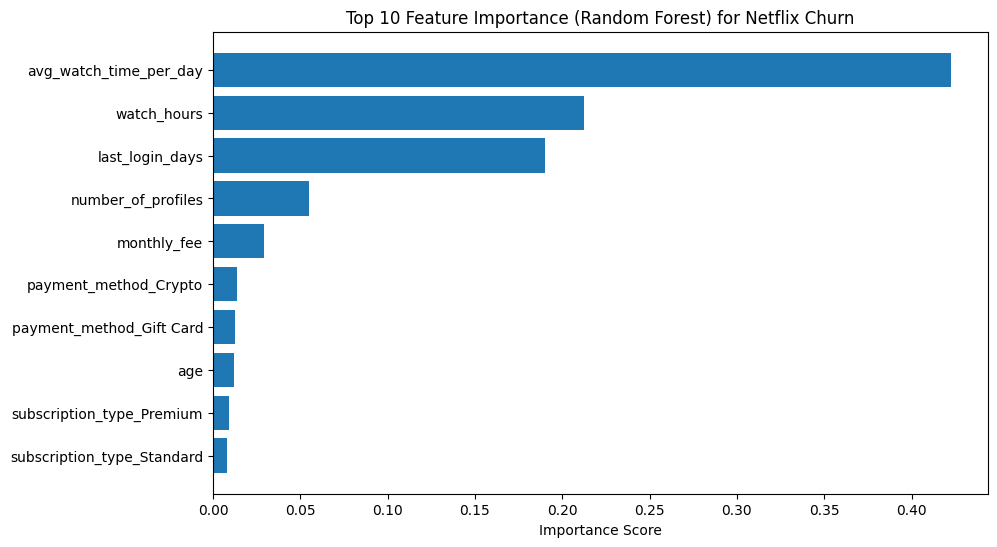

In [27]:
top_10 = feature_importance_df.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_10['feature'], top_10['importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance (Random Forest) for Netflix Churn")
plt.xlabel("Importance Score")
plt.show()

### Summary:
- Random Forest Classifier obtained an accuract of 97%
- Precision of 97-98%, Recall of 97-98% and f1-score of 97%
- False Negative --> False Negative (17) means the model failed to detect customers who actually churned, which is more critical in churn prediction than False Positives.
- The model shows strong generalization with balanced precision and recall across both classes.

The most influential features for predicting churn were average watch time per day, total watch hours, and last login days. This suggests that user engagement is the strongest indicator of whether a customer is likely to cancel their subscription.

From a business perspective, improving engagement (e.g., personalized recommendations, retention notifications, or content targeting) may help reduce churn.